# 1.6 Featured Data - Model Evaluation

Evaluate the tuned model on the **held-out test split** by re-applying the exact
training transformation with the saved configuration (the **config process**).

**Steps:**
1. Load `data_raw_test.csv` (held out since notebook 1_1) + saved configuration
2. Apply the training transform chain (preprocess → encode → features → scale)
3. Predict and compute final held-out metrics
4. Residual analysis + feature importance
5. Experiment summary


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1.6.1 Load Held-Out Test Data and Trained Model


In [2]:
df_test = pd.read_csv('../data/data_raw_test.csv')

with open('../artifacts/preprocessing/data_features.json', 'r') as f:
    FEATURE_COLS = json.load(f)

with open('../artifacts/preprocessing/data_scaler.json', 'r') as f:
    scaler_params = json.load(f)

with open('../artifacts/experiments/experiment_results.json', 'r') as f:
    experiment_results = json.load(f)

best_model = joblib.load('../artifacts/models/best_model.joblib')
best_model_name = experiment_results['best_model']

print(f'Loaded model: {best_model_name}')
print(f'Held-out test samples (from 1_1): {df_test.shape[0]}')
print(f'Feature count: {len(FEATURE_COLS)}')
df_test.head()


Loaded model: Gradient Boosting
Held-out test samples (from 1_1): 17
Feature count: 17


,price,sqft,bedrooms,bathrooms,location,year_built,condition
0,1120000,3050,4,3.0,Waterfront,2002,Good
1,495000,1527,2,1.5,Suburb,1956,Good
2,982000,2980,4,3.0,Mountain,2010,Excellent
3,348000,1750,2,1.5,Rural,1972,Fair
4,298000,1650,2,1.5,Rural,1958,Fair


## 1.6.2 Config Process — Transform the Test Split with the Training Configuration

The test split was saved **raw** in notebook 1_1 and never touched by 1_2/1_4.
To evaluate the model we re-apply the exact same transform chain used in training:

1. **Preprocess** (mirrors 1_2): drop missing `price`, fix dtypes, cap outliers (IQR rule), `house_age = 2026 - year_built`
2. **Encode** (mirrors 1_4): one-hot `location` (6 fixed categories), ordinal `condition_encoded`
3. **Features** (mirrors 1_4): `total_rooms`, `bath_bed_ratio`, `is_luxury`, `is_new`, `sqft_per_bedroom`, `log_price`
4. **Scale** (mirrors 1_4): standardize the 7 numerics with the **scaler fitted on train** (mean/std from `data_scaler.json`) — no refit on test
5. Select the columns in `FEATURE_COLS` order (from `data_features.json`)


In [3]:
CURRENT_YEAR = 2026

def cap_outliers(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return series.clip(lower, upper)


df = df_test.copy()
df = df.dropna(subset=['price'])
df['price'] = df['price'].astype(float)
df['sqft'] = df['sqft'].astype(int)
df['bedrooms'] = df['bedrooms'].astype(int)
df['bathrooms'] = df['bathrooms'].astype(float)
df['year_built'] = df['year_built'].astype(int)

for col in ['price', 'sqft']:
    df[col] = cap_outliers(df[col])

df['house_age'] = CURRENT_YEAR - df['year_built']
print(f'Preprocessed test shape: {df.shape}')


Preprocessed test shape: (17, 8)


**Encoding (location one-hot + condition ordinal) and derived features:**


In [4]:
LOCATION_CATEGORIES = ['Downtown', 'Mountain', 'Rural', 'Suburb', 'Urban', 'Waterfront']
condition_order = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}

df['location'] = pd.Categorical(df['location'], categories=LOCATION_CATEGORIES)
df = pd.get_dummies(df, columns=['location'], prefix='loc', drop_first=False)
df['condition_encoded'] = df['condition'].map(condition_order)
df.drop(columns=['condition'], inplace=True)

df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['bath_bed_ratio'] = df['bathrooms'] / df['bedrooms'].replace(0, 1)
df['is_luxury'] = ((df['condition_encoded'] >= 3) & (df['sqft'] >= 2500)).astype(int)
df['is_new'] = (df['house_age'] <= 15).astype(int)
df['sqft_per_bedroom'] = df['sqft'] / df['bedrooms'].replace(0, 1)
df['log_price'] = np.log1p(df['price'])

print(f'Encoded + featured test shape: {df.shape}')


Encoded + featured test shape: (17, 19)


**Scaling with the train-fitted scaler and final feature selection:**


In [5]:
features_to_scale = scaler_params['features']

scaler = StandardScaler()
scaler.mean_ = np.array([scaler_params['mean'][col] for col in features_to_scale])
scaler.scale_ = np.array([scaler_params['std'][col] for col in features_to_scale])

df[features_to_scale] = scaler.transform(df[features_to_scale])

df = df.reindex(columns=['price', 'log_price'] + FEATURE_COLS, fill_value=0)

X_test = df[FEATURE_COLS]
y_test = df['log_price']

print('Applied scaler fitted on train (no refit on test).')
print(f'Test feature matrix: {X_test.shape}')
print(f'Missing values in test matrix: {X_test.isnull().sum().sum()}')


Applied scaler fitted on train (no refit on test).
Test feature matrix: (17, 17)
Missing values in test matrix: 0


## 1.6.3 Final Model Evaluation


In [6]:
y_pred_test_log = best_model.predict(X_test)
y_pred_test = np.expm1(y_pred_test_log)
y_test_orig = np.expm1(y_test)

test_r2 = r2_score(y_test_orig, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_test))
test_mae = mean_absolute_error(y_test_orig, y_pred_test)
test_mape = mean_absolute_percentage_error(y_test_orig, y_pred_test)

print(f"{'='*50}")
print(f"Final Evaluation: {best_model_name} (Tuned)")
print(f"{'='*50}")
print(f"  Test R2:   {test_r2:.4f}")
print(f"  Test RMSE: ${test_rmse:>12,.2f}")
print(f"  Test MAE:  ${test_mae:>12,.2f}")
print(f"  Test MAPE: {test_mape:.4f}")
print(f"{'='*50}")


Final Evaluation: Gradient Boosting (Tuned)
  Test R2:   0.9044
  Test RMSE: $   72,709.62
  Test MAE:  $   44,664.52
  Test MAPE: 0.0666


## 1.6.4 Predicted vs Actual and Residual Analysis


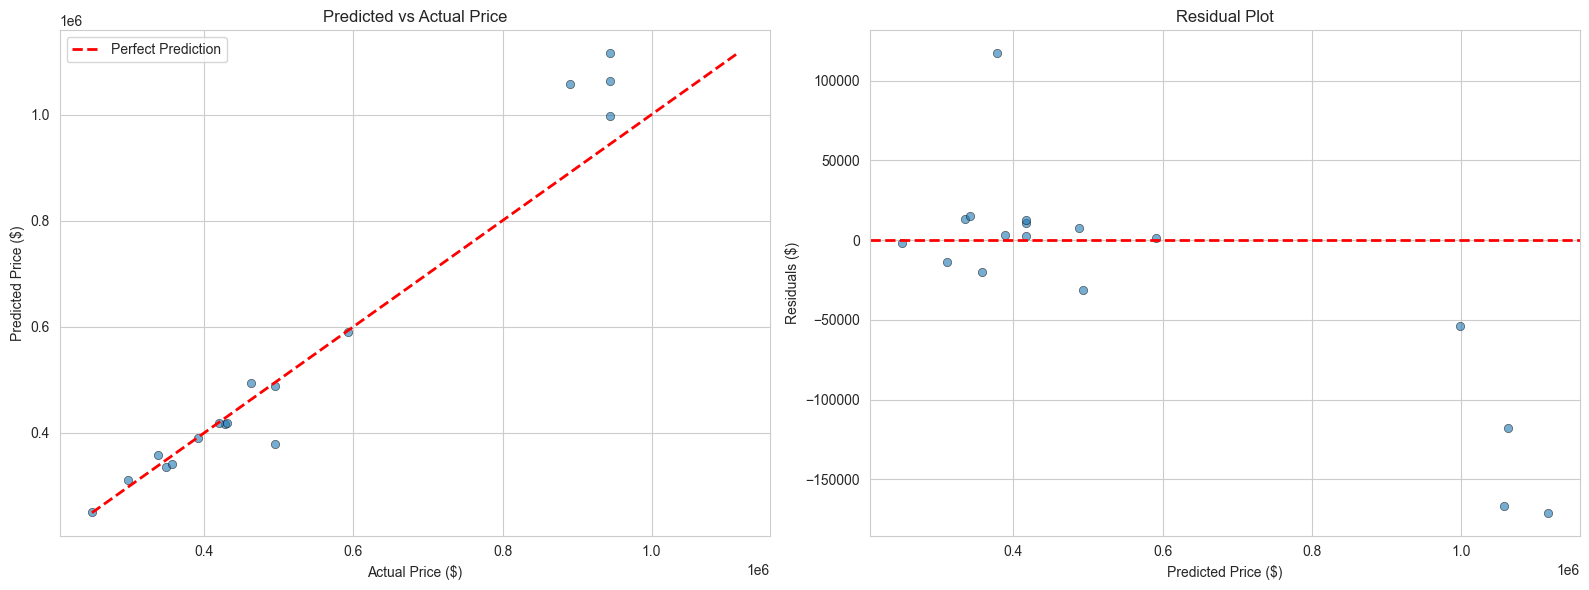


Residual Statistics:
  Mean: $  -23,118.95
  Std:  $   71,057.83
  Min:  $ -170,981.15
  Max:  $  117,165.14


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test_orig, y_pred_test, alpha=0.6, edgecolor='k', linewidth=0.5)
min_val = min(y_test_orig.min(), y_pred_test.min())
max_val = max(y_test_orig.max(), y_pred_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Predicted vs Actual Price')
axes[0].legend()

residuals = y_test_orig - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.6, edgecolor='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

print(f'\nResidual Statistics:')
print(f'  Mean: ${residuals.mean():>12,.2f}')
print(f'  Std:  ${residuals.std():>12,.2f}')
print(f'  Min:  ${residuals.min():>12,.2f}')
print(f'  Max:  ${residuals.max():>12,.2f}')


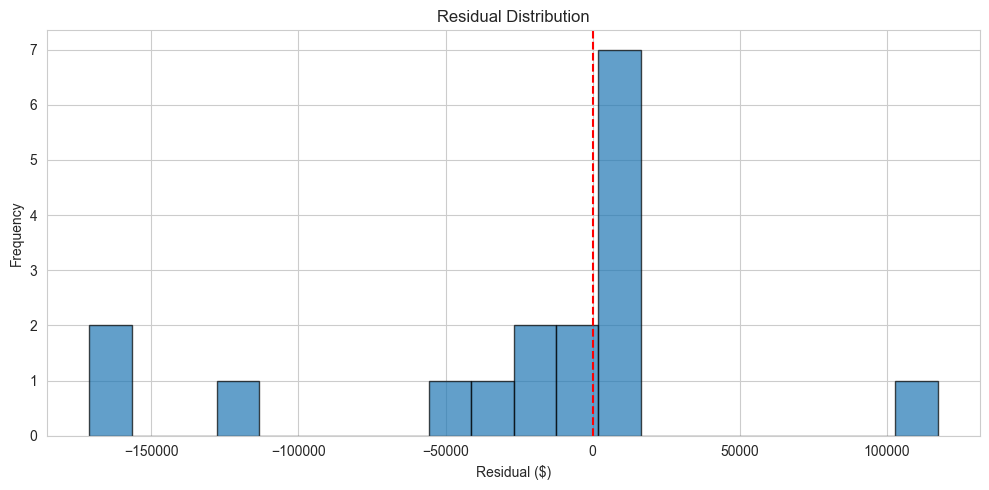

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual ($)')
ax.set_ylabel('Frequency')
ax.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()


## 1.6.5 Feature Importance


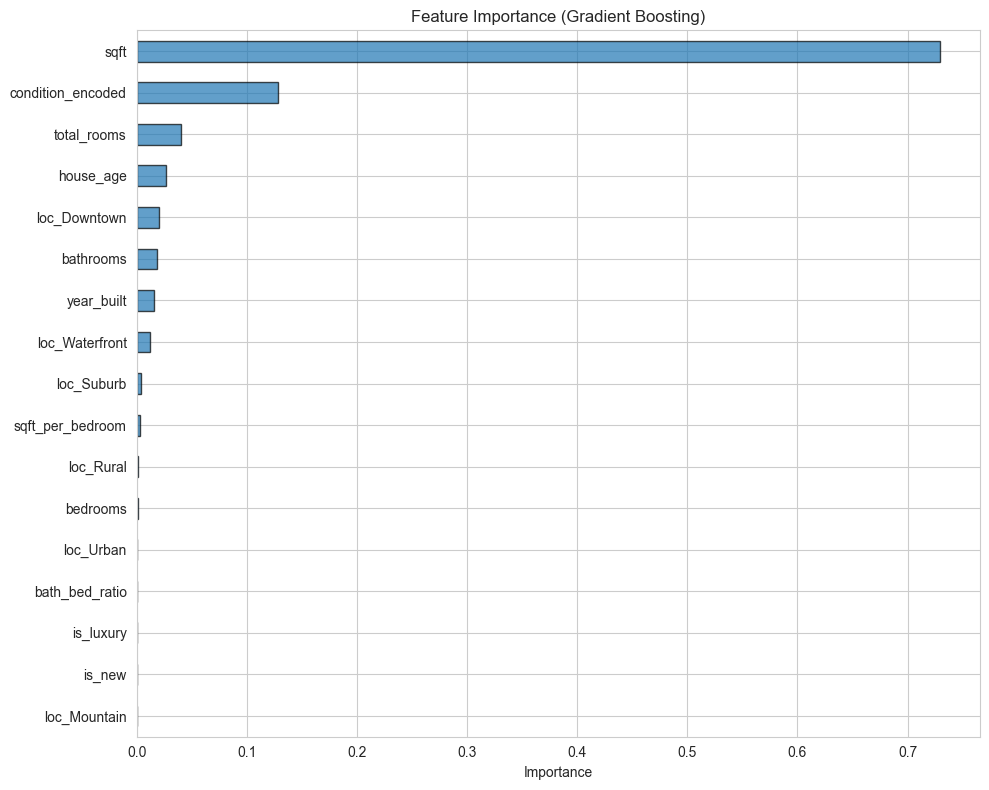

In [9]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    importances.plot(kind='barh', ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(f'Feature Importance ({best_model_name})')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(np.abs(best_model.coef_), index=FEATURE_COLS)
    coefs = coefs.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    coefs.plot(kind='barh', ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(f'Feature Coefficients ({best_model_name})')
    ax.set_xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()
else:
    print('Model does not expose feature importance or coefficients.')


## 1.6.6 Experiment Summary


In [10]:
print('\n' + '='*60)
print('EXPERIMENT SUMMARY')
print('='*60)
print(f'Best Model: {best_model_name}')
print(f'Best CV R2: {experiment_results["best_cv_r2"]:.4f}')
print(f'Best Test R2: {test_r2:.4f}')
print(f'Best Test RMSE: ${test_rmse:,.2f}')
print(f'Best Test MAE: ${test_mae:,.2f}')
print(f'Best Test MAPE: {test_mape*100:.2f}%')
print(f'Number of features: {len(FEATURE_COLS)}')
print(f'Test samples (held-out): {X_test.shape[0]}')
print('='*60)

experiment_results['test_metrics'] = {
    'test_r2': float(test_r2),
    'test_rmse': float(test_rmse),
    'test_mae': float(test_mae),
    'test_mape': float(test_mape),
    'test_samples': int(X_test.shape[0]),
}
results_path = '../artifacts/experiments/experiment_results.json'
with open(results_path, 'w') as f:
    json.dump(experiment_results, f, indent=2, default=str)
print(f'Appended test metrics to {results_path}')



EXPERIMENT SUMMARY
Best Model: Gradient Boosting
Best CV R2: 0.9982
Best Test R2: 0.9044
Best Test RMSE: $72,709.62
Best Test MAE: $44,664.52
Best Test MAPE: 6.66%
Number of features: 17
Test samples (held-out): 17
Appended test metrics to ../artifacts/experiments/experiment_results.json
